<a href="https://colab.research.google.com/github/jacksonhoward1856/GEOL558/blob/main/JAH_Scikit_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Image Processing with scikit-image (Geoscience Applications)**

## **Introduction**
This notebook explores various image processing techniques using **scikit-image** on geoscience-related images.

**Selected Techniques:**
- **Edge Detection**: Identifying rock boundaries and fractures.
- **Watershed Segmentation**: Classifying minerals or sedimentary grains.
- **Feature Detection**: Detecting faults and fractures.
- **Denoising**: Enhancing satellite imagery.
- **Image Registration**: Aligning geological maps.


In [41]:
from google.colab import drive
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, filters, color
from skimage import io, segmentation, color
from skimage.filters import sobel
from skimage.feature import corner_harris, corner_peaks
from skimage.restoration import denoise_nl_means
from skimage.registration import phase_cross_correlation
from skimage.transform import AffineTransform, warp
from scipy.ndimage import shift

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
# Set image directory path
image_dir = '/content/drive/MyDrive/GEOL558 Colab/ Geoscience_Images'

# List available images
print("Available Images:", os.listdir(image_dir))

Available Images: ['scikit_image_geoscience_final_corrected.ipynb', 'band1c.raw', 'Edge Detection on Rock Outcrop Image.jpg', 'Feature Detection on Fault Line Aerial Image.jpg', 'Watershed Segmentation for Mineral Classification.jpg', 'Image Registration for Aligning Geological Maps.jpg']


## Edge Detection on Rock Outcrop Image

**Source Image:** `Edge Detection on Rock Outcrop Image.jpg`

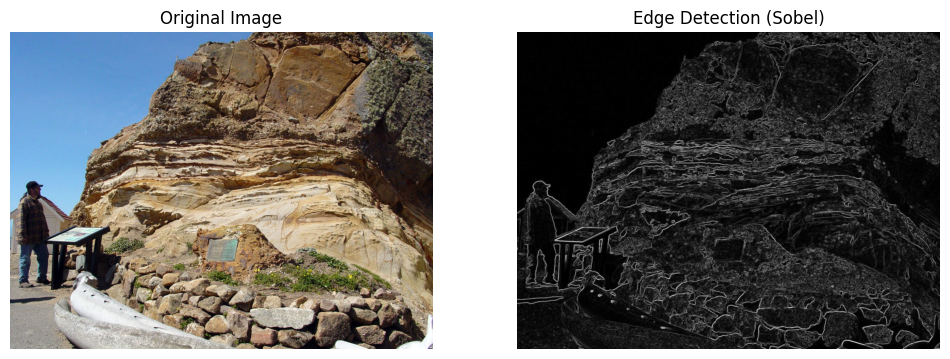

In [43]:
# Define the image file path in Google Drive
image_dir = "/content/drive/MyDrive/Geoscience_Images"
image_path = os.path.join(image_dir, "/content/drive/MyDrive/GEOL558 Colab/ Geoscience_Images/Edge Detection on Rock Outcrop Image.jpg")

# Load the rock outcrop image
image = io.imread(image_path)

# Convert to grayscale
gray_image = color.rgb2gray(image)

# Apply Sobel edge detection
edges = filters.sobel(gray_image)

# Display results
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(edges, cmap="gray")
ax[1].set_title("Edge Detection (Sobel)")
ax[1].axis("off")

plt.show()

## Watershed Segmentation for Mineral Classification

**Source Image:** `Watershed Segmentation for Mineral Classification.jpg`

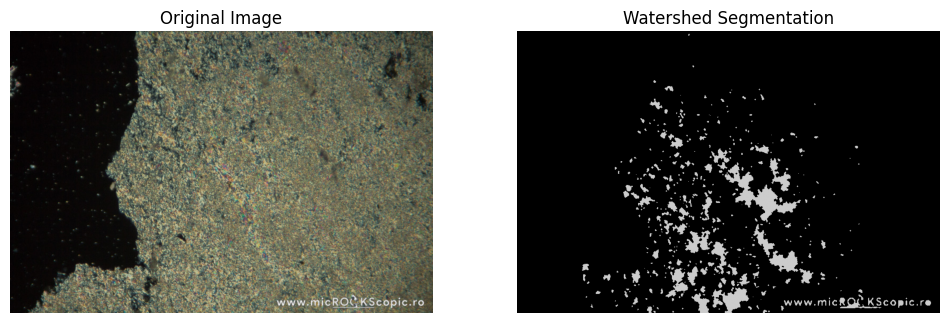

In [44]:
# Define the image file path in Google Drive
image_dir = "/content/drive/MyDrive/Geoscience_Images"
image_path = os.path.join(image_dir, "/content/drive/MyDrive/GEOL558 Colab/ Geoscience_Images/Watershed Segmentation for Mineral Classification.jpg")

# Load the mineral thin-section image
image = io.imread(image_path)

# Convert to grayscale
gray = color.rgb2gray(image)

# Compute the elevation map using Sobel filter
elevation_map = sobel(gray)

# Define markers for segmentation
markers = np.zeros_like(gray, dtype=np.int32)  # Ensure markers are integer
markers[gray < 0.3] = 1  # Assign low-intensity regions as background
markers[gray > 0.7] = 2  # Assign high-intensity regions as foreground

# Apply watershed segmentation
segmented = segmentation.watershed(elevation_map, markers)

# Display results
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(segmented, cmap="nipy_spectral")
ax[1].set_title("Watershed Segmentation")
ax[1].axis("off")

plt.show()

## Feature Detection on Fault Line Aerial Image

**Source Image:** `Feature Detection on Fault Line Aerial Image.jpg`

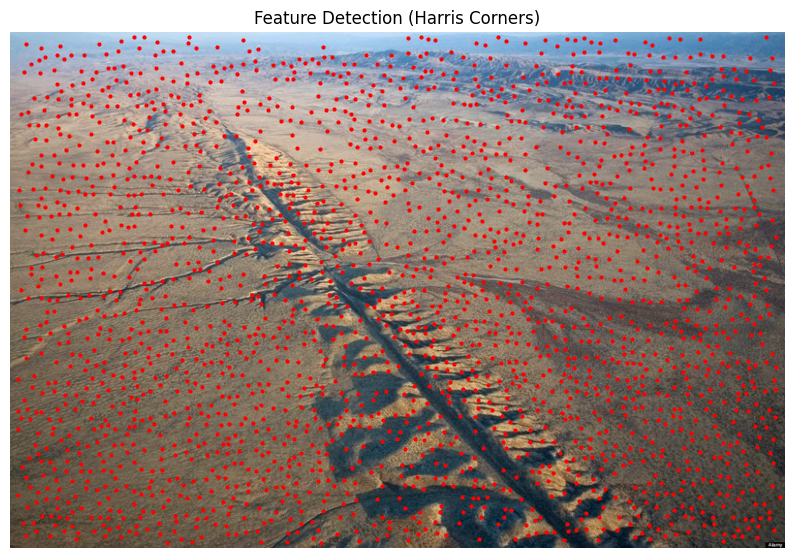

In [45]:
# Define the image file path in Google Drive
image_dir = "/content/drive/MyDrive/Geoscience_Images"
image_path = os.path.join(image_dir, "/content/drive/MyDrive/GEOL558 Colab/ Geoscience_Images/Feature Detection on Fault Line Aerial Image.jpg")

# Load the aerial image of the fault line
image = io.imread(image_path)

# Convert to grayscale
gray = color.rgb2gray(image)

# Apply Harris corner detection
corners = corner_peaks(corner_harris(gray), min_distance=5)

# Display results
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(image)
ax.plot(corners[:, 1], corners[:, 0], "ro", markersize=2)
ax.set_title("Feature Detection (Harris Corners)")
ax.axis("off")

plt.show()

## Denoising a Noisy Satellite Image

**Source Image:** `band1c.raw`

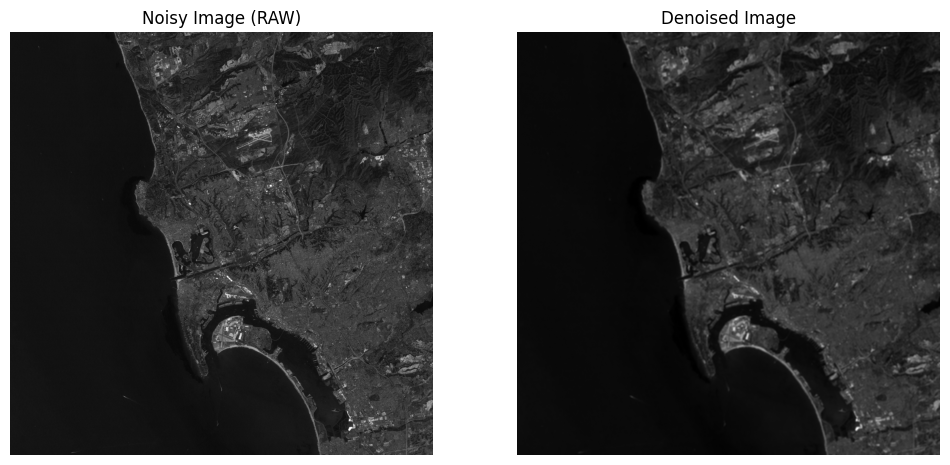

In [46]:
# Define the RAW file path in Google Drive
image_dir = "/content/drive/MyDrive/Geoscience_Images"
raw_file_path = os.path.join(image_dir, "/content/drive/MyDrive/GEOL558 Colab/ Geoscience_Images/band1c.raw")

# Load RAW data
with open(raw_file_path, "rb") as f:
    raw_data = f.read()

# Estimate image dimensions (assuming a square image)
image_size = int(np.sqrt(len(raw_data)))

# Convert raw binary data into a 2D grayscale image
image_array = np.frombuffer(raw_data, dtype=np.uint8)
image_array = image_array[:image_size**2].reshape((image_size, image_size))

# Normalize the image for processing
gray = image_array.astype(np.float32) / 255.0

# Apply Non-Local Means Denoising with correct parameters
denoised = denoise_nl_means(gray, h=1.15, fast_mode=True, patch_size=5, patch_distance=3, channel_axis=None)

# Display results
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(gray, cmap="gray")
ax[0].set_title("Noisy Image (RAW)")
ax[0].axis("off")

ax[1].imshow(denoised, cmap="gray")
ax[1].set_title("Denoised Image")
ax[1].axis("off")

plt.show()

## Image Registration for Aligning Geological Maps

**Source Image:** `Image Registration for Aligning Geological Maps.jpg`

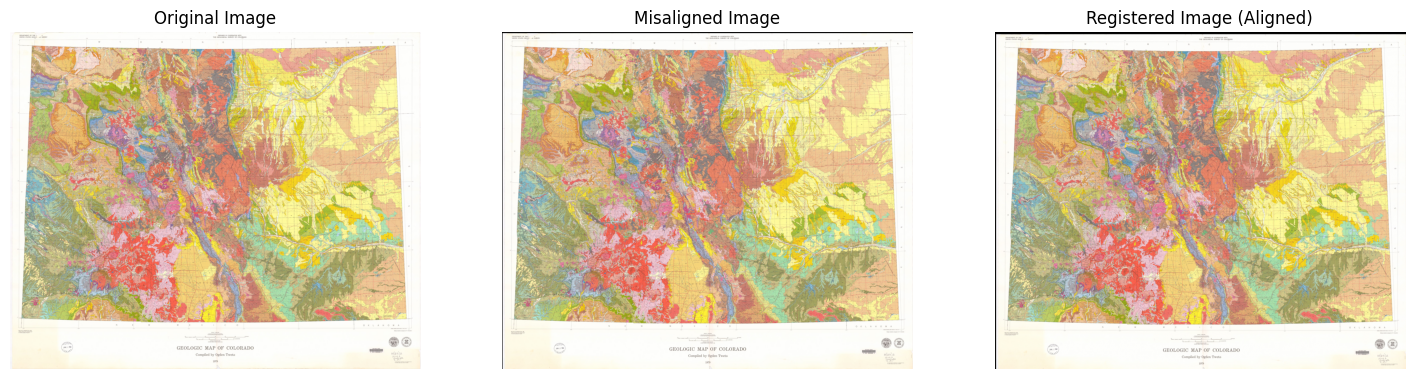

In [47]:
# Define the image file path in Google Drive
image_dir = "/content/drive/MyDrive/Geoscience_Images"
image_path = os.path.join(image_dir, "/content/drive/MyDrive/GEOL558 Colab/ Geoscience_Images/Image Registration for Aligning Geological Maps.jpg")

# Load the geological map image
image1 = io.imread(image_path)

# Simulate a shifted version of the image
image2 = shift(image1, shift=(10, 5, 0))  # Shift by (10,5) pixels

# Compute the shift between the images
shift_val, _, _ = phase_cross_correlation(image1, image2[:, :, :3])

# Apply transformation to align the images
transform = AffineTransform(translation=(-shift_val[1], -shift_val[0]))  # Invert shift
registered = warp(image2, transform.inverse)

# Display results
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(image1)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(image2)
ax[1].set_title("Misaligned Image")
ax[1].axis("off")

ax[2].imshow(registered)
ax[2].set_title("Registered Image (Aligned)")
ax[2].axis("off")

plt.show()

# **Reflection**

This assignment provided an opportunity to explore scikit-image techniques in these applications. I personally liked the edge detection method, because it effectively highlights geological boundaries and features like faults and fractures.

### **What I Liked:**
- Watershed segmentation was neat as it allowed me to classify different mineral phases in a thin-section image.
- Denoising was highly practical for cleaning up satellite images, which is useful in remote sensing, which I am currently in a class about.
- Image registration was an interesting thing for aligning multiple geological maps for comparison, which I can use for my thesis work at the moment.

### **What I Might Use in the Future:**
- Feature detection seems useful for identifying geological features in large datasets like fault lines and rock joints.
- Denoising and edge detection could be useful for improving seismic imaging data, which I have some data that can use that for my thesis.

### **Challenges & Weird Aspects:**
- Watershed segmentation had me dealing with tuning of threshold values to work correctly and not look odd.
- Image registration was tricky, as different images that I tried had distortions that simple transformations couldn't correct.